# Feature Engineering


In [ ]:
# Parameters (papermill-friendly)
seed = 42
data_dir = 'data'
processed_dir = 'data/processed'


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/FICO_cleaned.csv", engine='pyarrow')

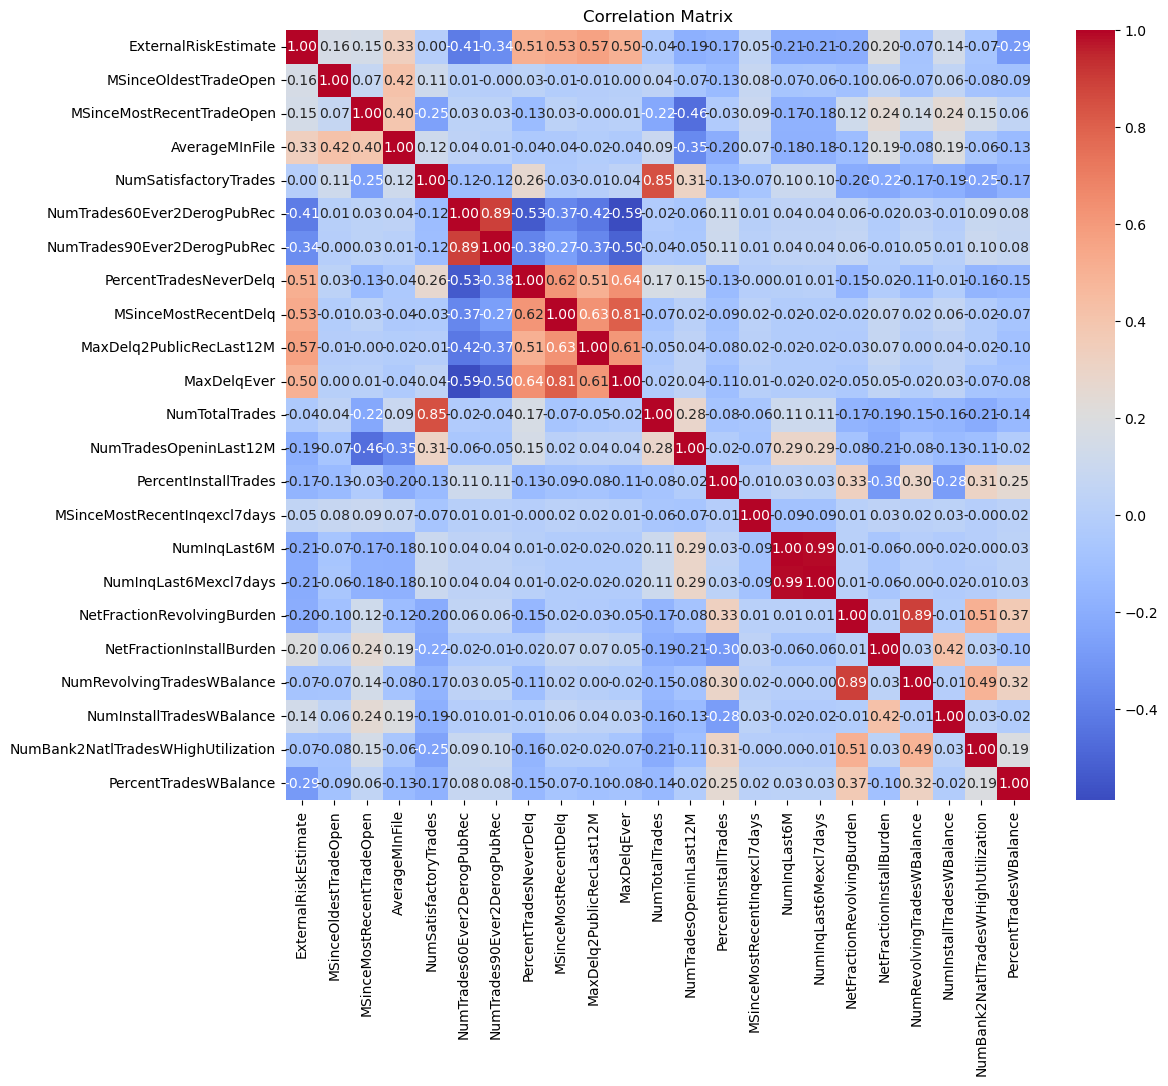

In [3]:
# Check corr matrix with sns
import seaborn as sns

corr = df.drop(columns=['RiskPerformance'], inplace=False).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9861 entries, 0 to 9860
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   RiskPerformance                     9861 non-null   int64  
 1   ExternalRiskEstimate                9861 non-null   float64
 2   MSinceOldestTradeOpen               9861 non-null   float64
 3   MSinceMostRecentTradeOpen           9861 non-null   float64
 4   AverageMInFile                      9861 non-null   float64
 5   NumSatisfactoryTrades               9861 non-null   float64
 6   NumTrades60Ever2DerogPubRec         9861 non-null   float64
 7   NumTrades90Ever2DerogPubRec         9861 non-null   float64
 8   PercentTradesNeverDelq              9861 non-null   float64
 9   MSinceMostRecentDelq                9861 non-null   float64
 10  MaxDelq2PublicRecLast12M            9861 non-null   float64
 11  MaxDelqEver                         9861 no

In [5]:
# Generate correlation matrix for full dataset
corr = df.corr()

# Identify features with absolute correlation to RiskPerformance greater than 0.2
important_features = corr.index[abs(corr["RiskPerformance"]) > 0.2].tolist()
important_features.remove("RiskPerformance")  # Remove target variable

print("Important features correlated with RiskPerformance:")
print(important_features)

Important features correlated with RiskPerformance:
['ExternalRiskEstimate', 'AverageMInFile', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver']


In [7]:
# Export cleaned dataset with only important features and target
df_important = df[important_features + ['RiskPerformance']]
df_important.to_csv("../data/processed/FICO_reduced.csv", index=False)

### Building monotonic constraints

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

df = pd.read_csv("../data/processed/FICO_cleaned.csv", engine='pyarrow')
reference = pd.read_csv("../data/raw/FICO_uncleaned.csv", engine='pyarrow')

# Assuming df is loaded and we already flipped:
y_raw = df["RiskPerformance"]   # 0 = Bad, 1 = Good
y = 1 - y_raw                   # 1 = Bad, 0 = Good

print("Reference RiskPerformance distribution:")
print(reference["RiskPerformance"].value_counts(normalize=True))
print("\nFlipped RiskPerformance distribution:")
print(y.value_counts(normalize=True))

X = df.drop(columns=["RiskPerformance"], inplace=False)

print("Features:", list(X.columns))
print("Target Bad=1, Good=0")

Reference RiskPerformance distribution:
RiskPerformance
Bad     0.521943
Good    0.478057
Name: proportion, dtype: float64

Flipped RiskPerformance distribution:
RiskPerformance
1    0.520028
0    0.479972
Name: proportion, dtype: float64
Features: ['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NumInqLast6Mexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance']
Target Bad=1, Good=0


In [12]:
monotone_dir = {}  # feature -> {-1, 0, +1}

for col in X.columns:
    # Drop NaNs for correlation computation
    valid_mask = ~X[col].isna()
    if valid_mask.sum() < 10:
        # Too few valid points -> no constraint
        monotone_dir[col] = 0
        continue

    corr, _ = spearmanr(X.loc[valid_mask, col], y.loc[valid_mask])

    # Small correlations → treat as "no strong direction"
    if np.isnan(corr) or abs(corr) < 0.02:
        monotone_dir[col] = 0
    else:
        monotone_dir[col] = 1 if corr > 0 else -1

monotone_dir

{'ExternalRiskEstimate': -1,
 'MSinceOldestTradeOpen': -1,
 'MSinceMostRecentTradeOpen': -1,
 'AverageMInFile': -1,
 'NumSatisfactoryTrades': -1,
 'NumTrades60Ever2DerogPubRec': 1,
 'NumTrades90Ever2DerogPubRec': 1,
 'PercentTradesNeverDelq': -1,
 'MSinceMostRecentDelq': -1,
 'MaxDelq2PublicRecLast12M': -1,
 'MaxDelqEver': -1,
 'NumTotalTrades': -1,
 'NumTradesOpeninLast12M': 1,
 'PercentInstallTrades': 1,
 'MSinceMostRecentInqexcl7days': -1,
 'NumInqLast6M': 1,
 'NumInqLast6Mexcl7days': 1,
 'NetFractionRevolvingBurden': 1,
 'NetFractionInstallBurden': -1,
 'NumRevolvingTradesWBalance': 1,
 'NumInstallTradesWBalance': 1,
 'NumBank2NatlTradesWHighUtilization': 1,
 'PercentTradesWBalance': 1}

In [13]:
print("Monotonic directions (Spearman vs Bad=1):")
for col in X.columns:
    print(f"{col:35s}: {monotone_dir[col]}")

# Build monotone_constraints string in the exact feature order
constraints_list = [monotone_dir[col] for col in X.columns]
monotone_constraints_str = "(" + ",".join(str(v) for v in constraints_list) + ")"

print("\nmonotone_constraints:", monotone_constraints_str)
print("Number of features:", len(constraints_list))

Monotonic directions (Spearman vs Bad=1):
ExternalRiskEstimate               : -1
MSinceOldestTradeOpen              : -1
MSinceMostRecentTradeOpen          : -1
AverageMInFile                     : -1
NumSatisfactoryTrades              : -1
NumTrades60Ever2DerogPubRec        : 1
NumTrades90Ever2DerogPubRec        : 1
PercentTradesNeverDelq             : -1
MSinceMostRecentDelq               : -1
MaxDelq2PublicRecLast12M           : -1
MaxDelqEver                        : -1
NumTotalTrades                     : -1
NumTradesOpeninLast12M             : 1
PercentInstallTrades               : 1
MSinceMostRecentInqexcl7days       : -1
NumInqLast6M                       : 1
NumInqLast6Mexcl7days              : 1
NetFractionRevolvingBurden         : 1
NetFractionInstallBurden           : -1
NumRevolvingTradesWBalance         : 1
NumInstallTradesWBalance           : 1
NumBank2NatlTradesWHighUtilization : 1
PercentTradesWBalance              : 1

monotone_constraints: (-1,-1,-1,-1,-1,1,1,-1,-1,